In [236]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from tabpfn import TabPFNRegressor
from tabpfn.model_loading import (
    load_fitted_tabpfn_model,
    save_fitted_tabpfn_model,
)
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

In [237]:
torch.cuda.is_available()

True

In [238]:
class config:
    data_path='AMZN_2006-01-01_to_2018-01-01.csv'
    model_path='C:/Users/foksm/AppData/Roaming/tabpfn/tabpfn-v2.5-regressor-v2.5_default.ckpt'
    
    lags=[22, 32, 2, 38, 3, 31, 1, 48, 49, 50, 42, 47, 26, 5]
    windows=[3, 47]
    device='cuda'

In [239]:
df = pd.read_csv(config.data_path)

In [240]:
df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3019.000000,3019.000000,3019.000000,3.019000e+03
mean,299.335310,302.371163,296.037695,299.376231,5.931712e+06
std,280.120547,281.826442,277.927134,279.980161,5.122034e+06
min,26.090000,26.300000,25.760000,26.070000,9.864350e+05
25%,81.175000,82.580000,79.725000,81.090000,3.137037e+06
50%,205.330000,208.000000,202.100000,205.440000,4.724100e+06
75%,375.570000,379.155000,373.000000,375.140000,7.135246e+06
max,1204.880000,1213.410000,1191.150000,1195.830000,1.044046e+08


In [241]:
df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


<Figure size 3000x1500 with 0 Axes>

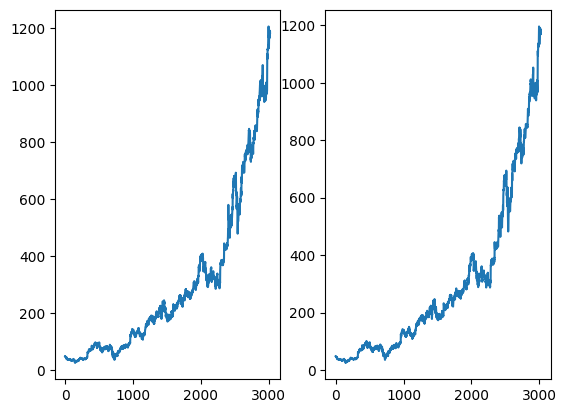

In [242]:
fig = plt.figure(figsize=(30, 15))
f, (ax1, ax2) = plt.subplots(1, 2, sharey=False)
ax1.plot(df['Open'])
ax2.plot(df['Close'])

In [243]:
df['Date'] = pd.to_datetime(df['Date'])

In [244]:
cols_to_lag = df.columns.drop(['Date', 'Name'])
cols_to_window = df.columns.drop(['Date', 'Name'])

In [245]:
df['Day_of_week'] = df['Date'].dt.dayofweek

In [246]:
df_start = df.copy()

In [247]:
"""study = optuna.create_study(study_name="study", direction="maximize")"""

'study = optuna.create_study(study_name="study", direction="maximize")'

In [248]:
"""def obj(trial):
    df = df_start.copy()
    lag_1 = trial.suggest_int('lag_1', 1, 50)
    lag_2 = trial.suggest_int('lag_2', 1, 50)
    lag_3 = trial.suggest_int('lag_3', 1, 50)
    lag_4 = trial.suggest_int('lag_4', 1, 50)
    lag_5 = trial.suggest_int('lag_5', 1, 50)
    lag_6 = trial.suggest_int('lag_6', 1, 50)
    lag_7 = trial.suggest_int('lag_7', 1, 50)
    lag_8 = trial.suggest_int('lag_8', 1, 50)
    lag_9 = trial.suggest_int('lag_9', 1, 50)
    lag_10 = trial.suggest_int('lag_10', 1, 50)
    lag_11 = trial.suggest_int('lag_11', 1, 50)
    lag_12 = trial.suggest_int('lag_12', 1, 50)
    lag_13 = trial.suggest_int('lag_13', 1, 50)
    lag_14 = trial.suggest_int('lag_14', 1, 50)
    lag_15 = trial.suggest_int('lag_15', 1, 50)
    lag_16 = trial.suggest_int('lag_16', 1, 50)
    lag_17 = trial.suggest_int('lag_17', 1, 50)
    lag_18 = trial.suggest_int('lag_18', 1, 50)
    lag_19 = trial.suggest_int('lag_19', 1, 50)

    lags = [lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,
            lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17, lag_18, lag_19]
    
    window_1 = trial.suggest_int('window_1', 2, 50)
    window_2 = trial.suggest_int('window_2', 2, 50)
    window_3 = trial.suggest_int('window_3', 2, 50)
    window_4 = trial.suggest_int('window_4', 2, 50)
    window_5 = trial.suggest_int('window_5', 2, 50)

    windows = [window_1,window_2,window_3,window_4,window_5]
    for lag in lags:
        for col in cols_to_lag:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
            
    for window in windows:
        for col in cols_to_window:
            df[f'{col}_window_mean{window}'] = df[col].rolling(window).mean()
            df[f'{col}_window_std{window}'] = df[col].rolling(window).std()
            df[f'{col}_window_var{window}'] = df[col].rolling(window).var()
    
    X = df[df.columns.drop(['Date', 'Close', 'Name'])]
    y = df['Close']
    split = int(df.index.max() * 0.9)
    X_train, X_val = X.iloc[:split], X.iloc[split: ]
    y_train, y_val = y.iloc[:split], y.iloc[split: ]
    reg = TabPFNRegressor(device=config.device)
    reg.fit(X_train, y_train)
    pred = reg.predict(X_val)
    metric3 = r2_score(y_val, pred)

    return metric3"""

"def obj(trial):\n    df = df_start.copy()\n    lag_1 = trial.suggest_int('lag_1', 1, 50)\n    lag_2 = trial.suggest_int('lag_2', 1, 50)\n    lag_3 = trial.suggest_int('lag_3', 1, 50)\n    lag_4 = trial.suggest_int('lag_4', 1, 50)\n    lag_5 = trial.suggest_int('lag_5', 1, 50)\n    lag_6 = trial.suggest_int('lag_6', 1, 50)\n    lag_7 = trial.suggest_int('lag_7', 1, 50)\n    lag_8 = trial.suggest_int('lag_8', 1, 50)\n    lag_9 = trial.suggest_int('lag_9', 1, 50)\n    lag_10 = trial.suggest_int('lag_10', 1, 50)\n    lag_11 = trial.suggest_int('lag_11', 1, 50)\n    lag_12 = trial.suggest_int('lag_12', 1, 50)\n    lag_13 = trial.suggest_int('lag_13', 1, 50)\n    lag_14 = trial.suggest_int('lag_14', 1, 50)\n    lag_15 = trial.suggest_int('lag_15', 1, 50)\n    lag_16 = trial.suggest_int('lag_16', 1, 50)\n    lag_17 = trial.suggest_int('lag_17', 1, 50)\n    lag_18 = trial.suggest_int('lag_18', 1, 50)\n    lag_19 = trial.suggest_int('lag_19', 1, 50)\n\n    lags = [lag_1,lag_2,lag_3,lag_4,lag_5

In [249]:
"""study.optimize(obj, n_trials=500)"""

'study.optimize(obj, n_trials=500)'

In [250]:
"""lags = []
windows = []"""

'lags = []\nwindows = []'

In [251]:
"""for k in study.best_params.keys():
    if k[0] == 'l':
        if study.best_params[k] not in lags:
            lags.append(study.best_params[k])
    if k[0] == 'w':
        if study.best_params[k] not in windows:
            windows.append(study.best_params[k])"""
    

"for k in study.best_params.keys():\n    if k[0] == 'l':\n        if study.best_params[k] not in lags:\n            lags.append(study.best_params[k])\n    if k[0] == 'w':\n        if study.best_params[k] not in windows:\n            windows.append(study.best_params[k])"

In [252]:
"""print(sorted(lags))"""

'print(sorted(lags))'

In [253]:
"""print(sorted(windows))"""

'print(sorted(windows))'

In [254]:
for lag in config.lags:
    for col in cols_to_lag:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

In [255]:
for window in config.windows:
    for col in cols_to_window:
        df[f'{col}_window_mean{window}'] = df[col].rolling(window).mean()
        df[f'{col}_window_std{window}'] = df[col].rolling(window).std()
        df[f'{col}_window_var{window}'] = df[col].rolling(window).var()

C:\Users\foksm\AppData\Local\Temp\ipykernel_25644\1362960672.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_window_var{window}'] = df[col].rolling(window).var()
C:\Users\foksm\AppData\Local\Temp\ipykernel_25644\1362960672.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_window_mean{window}'] = df[col].rolling(window).mean()
C:\Users\foksm\AppData\Local\Temp\ipykernel_25644\1362960672.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

In [256]:
df.tail()

,Date,Open,High,Low,Close,Volume,Name,Day_of_week,Open_lag_22,High_lag_22,...,High_window_var47,Low_window_mean47,Low_window_std47,Low_window_var47,Close_window_mean47,Close_window_std47,Close_window_var47,Volume_window_mean47,Volume_window_std47,Volume_window_var47
3014,2017-12-22,1172.08,1174.62,1167.83,1168.36,1585054,AMZN,4,1132.86,1140.00,...,4280.682966,1113.101702,65.533359,4294.621136,1122.752128,66.256655,4389.944326,3.745118e+06,2.388830e+06,5.706508e+12
3015,2017-12-26,1168.36,1178.32,1160.55,1176.76,2005187,AMZN,1,1141.00,1160.27,...,4059.381122,1116.591064,63.528042,4035.812144,1126.576809,63.989328,4094.634066,3.734597e+06,2.395514e+06,5.738487e+12
3016,2017-12-27,1179.91,1187.29,1175.61,1182.26,1867208,AMZN,2,1160.70,1186.84,...,3653.948555,1120.747872,60.743020,3689.714461,1130.739574,60.979083,3718.448526,3.708193e+06,2.409368e+06,5.805052e+12
3017,2017-12-28,1189.00,1190.10,1184.38,1186.10,1841676,AMZN,3,1202.66,1213.41,...,3241.780512,1125.053830,57.795272,3340.293502,1135.062766,57.366366,3290.899925,3.697056e+06,2.416909e+06,5.841448e+12
3018,2017-12-29,1182.35,1184.00,1167.50,1169.47,2688391,AMZN,4,1204.88,1205.34,...,2730.354936,1129.415532,52.778718,2785.593086,1139.385532,51.753203,2678.394060,3.679913e+06,2.421233e+06,5.862370e+12


In [257]:
X = df[df.columns.drop(['Date', 'Close', 'Name'])]

In [258]:
split = int(df.index.max() * 0.9)

In [259]:
X.head()

,Open,High,Low,Volume,Day_of_week,Open_lag_22,High_lag_22,Low_lag_22,Close_lag_22,Volume_lag_22,...,High_window_var47,Low_window_mean47,Low_window_std47,Low_window_var47,Close_window_mean47,Close_window_std47,Close_window_var47,Volume_window_mean47,Volume_window_std47,Volume_window_var47
0,47.47,47.85,46.25,7582127,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47.48,47.73,46.69,7440914,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,47.16,48.20,47.11,5417258,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,47.97,48.58,47.32,6154285,4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,46.55,47.10,46.40,8945056,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [260]:
y = df['Close']

In [261]:
X_train, X_val = X.iloc[:split], X.iloc[split: ]
y_train, y_val = y.iloc[:split], y.iloc[split: ]

In [262]:
y_train.head()

0    47.58
1    47.25
2    47.65
3    47.87
4    47.08
Name: Close, dtype: float64

In [263]:
X_train.tail()

,Open,High,Low,Volume,Day_of_week,Open_lag_22,High_lag_22,Low_lag_22,Close_lag_22,Volume_lag_22,...,High_window_var47,Low_window_mean47,Low_window_std47,Low_window_var47,Close_window_mean47,Close_window_std47,Close_window_var47,Volume_window_mean47,Volume_window_std47,Volume_window_var47
2711,841.02,841.29,828.35,3588180,1,779.36,781.00,760.11,760.14,4257344.0,...,872.263054,782.145106,28.689870,823.108630,786.910000,29.029359,842.703687,2.619220e+06,991492.873367,9.830581e+11
2712,834.00,837.67,830.10,2380416,2,757.35,772.66,756.00,771.49,3124704.0,...,907.564656,783.570851,29.379094,863.131143,788.359149,29.655103,879.425121,2.612327e+06,992013.907409,9.840916e+11
2713,829.00,831.80,821.21,3091387,3,768.77,769.89,759.05,761.01,3117224.0,...,926.265541,784.851489,29.684982,881.198165,789.693617,30.061231,903.677628,2.635840e+06,989947.113209,9.799953e+11
2714,835.08,835.74,822.96,2999814,4,762.20,767.50,758.85,761.09,2531822.0,...,953.845630,786.044255,30.071745,904.309821,790.856383,30.272322,916.413454,2.659749e+06,984755.271398,9.697429e+11
2715,821.50,822.00,811.68,3361492,0,762.00,770.87,757.58,769.69,3043534.0,...,957.586053,787.012128,30.150789,909.070069,791.800851,30.254031,915.306373,2.697136e+06,977139.874766,9.548023e+11


In [264]:
X_val.head()

,Open,High,Low,Volume,Day_of_week,Open_lag_22,High_lag_22,Low_lag_22,Close_lag_22,Volume_lag_22,...,High_window_var47,Low_window_mean47,Low_window_std47,Low_window_var47,Close_window_mean47,Close_window_std47,Close_window_var47,Volume_window_mean47,Volume_window_std47,Volume_window_var47
2716,822.11,823.26,815.02,2512504,1,773.28,780.46,771.66,778.52,5499182.0,...,962.152789,787.988723,30.301639,918.189351,792.788298,30.325658,919.645558,2.707620e+06,972345.490204,9.454558e+11
2717,820.40,820.67,815.17,2090706,2,779.97,781.94,771.00,775.10,2297221.0,...,961.107877,788.983404,30.412417,924.915123,793.748511,30.385663,923.288522,2.718841e+06,961839.294373,9.251348e+11
2718,813.99,815.71,803.10,3151954,3,776.00,781.37,776.00,780.22,1937164.0,...,952.543143,789.736383,30.312205,918.829745,794.638511,30.242018,914.579678,2.740829e+06,959627.201112,9.208844e+11
2719,809.36,819.42,809.00,2793015,4,783.25,790.69,779.01,789.74,2718644.0,...,940.830049,790.697660,30.188598,911.351431,795.807660,30.095192,905.720579,2.766116e+06,944575.435376,8.922228e+11
2720,824.95,838.30,822.21,4060899,0,794.27,805.89,794.27,804.70,4078910.0,...,944.177802,792.038298,30.158501,909.535158,797.370638,30.347294,920.958263,2.812281e+06,953858.488280,9.098460e+11


In [265]:
reg = TabPFNRegressor(device=config.device)

In [266]:
reg.fit(X_train, y_train)

,n_estimators,8
,categorical_features_indices,None
,softmax_temperature,0.9
,average_before_softmax,False
,model_path,'auto'
,device,'cuda'
,ignore_pretraining_limits,False
,inference_precision,'auto'
,fit_mode,'fit_preprocessors'
,memory_saving_mode,'auto'
,random_state,0


In [267]:
pred = reg.predict(X_val)

In [268]:
metric1 = mean_absolute_error(y_val, pred)
metric2 = np.sqrt(mean_squared_error(y_val, pred))
metric3 = r2_score(y_val, pred)

In [269]:
metric1, metric2, metric3

(9.487785330290842, np.float64(12.81195779901303), 0.9889737481617646)

In [270]:
(9.487785330290842, np.float64(12.81195779901303), 0.9889737481617646)

(9.487785330290842, np.float64(12.81195779901303), 0.9889737481617646)